# Image Similarity Matching on Combined Oxford5k + Paris6k

This Colab notebook downloads Oxford5k + Paris6k online, combines both galleries, and evaluates multiple image similarity techniques on the **full combined retrieval benchmark**.

Methods included:

1. Color Histogram + HOG
2. SSIM
3. SIFT direct matching
4. BoVW with SIFT descriptors
5. EfficientNet transfer-learning embeddings
6. Siamese EfficientNet transfer-learning with contrastive loss
7. SigLIP image embeddings


## 0. Install dependencies


In [1]:
!pip -q install -U transformers timm scikit-image scikit-learn opencv-contrib-python-headless tqdm pandas matplotlib psutil

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 85.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 8.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas

## 1. Imports and config

In [2]:
import os
import gc
import math
import time
import random
import warnings
import threading
import contextlib
from pathlib import Path
from typing import Dict, List, Tuple, Iterable, Optional, Set

import numpy as np
import pandas as pd
from tqdm.auto import tqdm

from PIL import Image
import cv2

import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics.pairwise import cosine_similarity

from skimage.feature import hog
from skimage.metrics import structural_similarity as structural_similarity

import psutil

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

# Full benchmark setting.
# This notebook evaluates every Oxford5k + Paris6k query against the whole combined gallery.
# Warning: SSIM and SIFT direct matching are O(num_queries * num_gallery_images) and can take a long time.
FULL_DATASET_RUN = True
MAX_QUERY_IMAGES = None
MAX_DB_RANDOM_FILL = None

# Retrieval settings
TOP_KS = (1, 5, 10)
F1_K = 10
BATCH_SIZE = 64

# Colab/Python 3.12 can throw QueueFeederThread / semaphore errors with OpenCV + DataLoader workers.
# num_workers=0 is slower but much more stable for this mixed classical/deep notebook.
NUM_WORKERS = 0

# Image sizes for different pipelines
CLASSICAL_SIZE = (224, 224)
SSIM_SIZE = (128, 128)

# SIFT / BoVW settings.
# Keep SIFT_NFEATURES bounded; full pairwise SIFT matching is already expensive.
SIFT_NFEATURES = 1000
SIFT_RATIO_TEST = 0.75
BOVW_CLUSTERS = 512
BOVW_MAX_DESC_PER_IMAGE = 120
BOVW_VOCAB_TRAIN_IMAGES = 3000

# Siamese transfer-learning settings.
# This is a Siamese architecture whose shared image encoder starts from pretrained ImageNet weights.
# The projection head is trained with contrastive loss using RevisitOP query/gallery labels.
SIAMESE_EPOCHS = 2
SIAMESE_POS_PER_QUERY = 20
SIAMESE_NEG_PER_POS = 1
SIAMESE_MAX_PAIRS = None   # None = use all generated sampled pairs
SIAMESE_BATCH_SIZE = 32
SIAMESE_LR = 1e-3
SIAMESE_MARGIN = 1.0
SIAMESE_FREEZE_BACKBONE = True

# Method switches
RUN_COLOR_HOG = True
RUN_SSIM = True
RUN_SIFT_DIRECT = True
RUN_BOVW = True
RUN_EFFICIENTNET = True
RUN_SIAMESE = True
RUN_SIGLIP = True

WORKDIR = Path("/content/image_similarity_oxford_paris")
WORKDIR.mkdir(parents=True, exist_ok=True)
print("Workdir:", WORKDIR)
print("Full dataset run:", FULL_DATASET_RUN)

Device: cuda
Workdir: /content/image_similarity_oxford_paris
Full dataset run: True


## 2. Download/load Oxford5k + Paris6k online

Downloads the datasets directly from the original RevisitOP/Oxford links:

- `roxford5k`: Oxford5k images + revisited ground-truth pickle
- `rparis6k`: Paris6k images + revisited ground-truth pickle

Then it combines both datasets into one database/gallery and one query list.


In [3]:
import os
import pickle
import tarfile
import shutil
import subprocess
from pathlib import Path
from typing import Any

DATA_ROOT = WORKDIR / "revisitop_data"
DATASETS_ROOT = DATA_ROOT / "datasets"
DATASETS_ROOT.mkdir(parents=True, exist_ok=True)

DOWNLOAD_SOURCES = {
    "roxford5k": {
        "img_urls": ["https://www.robots.ox.ac.uk/~vgg/data/oxbuildings/oxbuild_images-v1.tgz"],
        "gnd_url": "https://cmp.felk.cvut.cz/revisitop/data/datasets/roxford5k/gnd_roxford5k.pkl",
    },
    "rparis6k": {
        "img_urls": [
            "https://www.robots.ox.ac.uk/~vgg/data/parisbuildings/paris_1-v1.tgz",
            "https://www.robots.ox.ac.uk/~vgg/data/parisbuildings/paris_2-v1.tgz",
        ],
        "gnd_url": "https://cmp.felk.cvut.cz/revisitop/data/datasets/rparis6k/gnd_rparis6k.pkl",
    },
}

def run_cmd(cmd: list[str]):
    print("$", " ".join(map(str, cmd)))
    subprocess.run(cmd, check=True)

def download_file(url: str, dst: Path):
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists() and dst.stat().st_size > 0:
        print(f"Already exists: {dst.name} ({dst.stat().st_size/1e6:.1f} MB)")
        return
    tmp = dst.with_suffix(dst.suffix + ".tmp")
    if tmp.exists():
        tmp.unlink()
    # wget is available in Colab and supports resume/retry better than plain urllib.
    run_cmd(["wget", "-c", "--tries=5", "--timeout=60", url, "-O", str(tmp)])
    tmp.rename(dst)

def safe_extract_flat_tgz(tgz_path: Path, dst_dir: Path):
    """Extract a tar.gz archive and move only files into dst_dir. Prevents path traversal."""
    marker = dst_dir / (tgz_path.name + ".extracted")
    if marker.exists():
        print(f"Already extracted: {tgz_path.name}")
        return

    dst_dir.mkdir(parents=True, exist_ok=True)
    tmp_dir = dst_dir / ("_tmp_extract_" + tgz_path.stem.replace(".", "_"))
    if tmp_dir.exists():
        shutil.rmtree(tmp_dir)
    tmp_dir.mkdir(parents=True, exist_ok=True)

    print(f"Extracting {tgz_path.name} ...")
    with tarfile.open(tgz_path, "r:gz") as tar:
        base = tmp_dir.resolve()
        for member in tar.getmembers():
            target = (tmp_dir / member.name).resolve()
            if not str(target).startswith(str(base)):
                raise RuntimeError(f"Blocked unsafe tar path: {member.name}")
        tar.extractall(tmp_dir)

    moved = 0
    for f in tmp_dir.rglob("*"):
        if f.is_file():
            out = dst_dir / f.name
            if not out.exists():
                shutil.move(str(f), str(out))
                moved += 1
    shutil.rmtree(tmp_dir)
    marker.write_text("ok")
    print(f"Moved {moved} image files into {dst_dir}")

def download_revisitop_dataset(dataset: str):
    spec = DOWNLOAD_SOURCES[dataset]
    dataset_dir = DATASETS_ROOT / dataset
    jpg_dir = dataset_dir / "jpg"
    jpg_dir.mkdir(parents=True, exist_ok=True)

    # Download and extract images.
    for url in spec["img_urls"]:
        archive_path = jpg_dir / Path(url).name
        download_file(url, archive_path)
        safe_extract_flat_tgz(archive_path, jpg_dir)
        # Keep archives by default so interrupted runs can resume; delete manually if storage is tight.

    # Download revisited ground truth.
    gnd_path = dataset_dir / f"gnd_{dataset}.pkl"
    download_file(spec["gnd_url"], gnd_path)
    return dataset_dir, jpg_dir, gnd_path

def as_int_list(x: Any) -> list[int]:
    if x is None:
        return []
    if isinstance(x, np.ndarray):
        return x.astype(int).tolist()
    if isinstance(x, (list, tuple, set)):
        return [int(v) for v in x]
    try:
        return [int(v) for v in list(x)]
    except Exception:
        return []

def load_revisitop_cfg(dataset: str):
    dataset_dir, jpg_dir, gnd_path = download_revisitop_dataset(dataset)
    with open(gnd_path, "rb") as f:
        cfg = pickle.load(f)
    cfg["dataset"] = dataset
    cfg["dir_images"] = str(jpg_dir)
    cfg["ext"] = ".jpg"
    cfg["qext"] = ".jpg"
    cfg["n"] = len(cfg["imlist"])
    cfg["nq"] = len(cfg["qimlist"])
    return cfg

def image_path_from_name(cfg: dict, name: str, query: bool = False) -> str:
    ext = cfg["qext"] if query else cfg["ext"]
    return str(Path(cfg["dir_images"]) / f"{name}{ext}")

def records_from_cfg(cfg: dict, db_offset: int):
    dataset = cfg["dataset"]
    db_records = []
    for i, name in enumerate(cfg["imlist"]):
        db_records.append({
            "dataset": dataset,
            "source_index": i,
            "global_index": db_offset + i,
            "name": name,
            "filename": f"{dataset}_{name}.jpg",
            "image_path": image_path_from_name(cfg, name, query=False),
        })

    q_records = []
    for qi, name in enumerate(cfg["qimlist"]):
        g = cfg["gnd"][qi]
        q_records.append({
            "dataset": dataset,
            "source_query_index": qi,
            "name": name,
            "filename": f"{dataset}_query_{qi:03d}_{name}.jpg",
            "image_path": image_path_from_name(cfg, name, query=True),
            "bbx": g.get("bbx", None),
            # Offset local dataset indices so the combined Oxford+Paris DB has one global index space.
            "easy": [db_offset + i for i in as_int_list(g.get("easy", []))],
            "hard": [db_offset + i for i in as_int_list(g.get("hard", []))],
            "medium": [db_offset + i for i in as_int_list(g.get("medium", []))],
            "junk": [db_offset + i for i in as_int_list(g.get("junk", []))],
        })
    return db_records, q_records

all_db_records = []
all_q_records = []
offset = 0
cfgs = {}
for dataset in ["roxford5k", "rparis6k"]:
    print("\n" + "=" * 80)
    print(f"Loading {dataset}")
    cfg = load_revisitop_cfg(dataset)
    cfgs[dataset] = cfg
    db_part, q_part = records_from_cfg(cfg, db_offset=offset)
    all_db_records.extend(db_part)
    all_q_records.extend(q_part)
    offset += len(db_part)
    print(f"{dataset}: {len(db_part)} DB images, {len(q_part)} queries")

# Keep old variable names so the rest of the notebook remains unchanged.
DATASET_REPO = "direct_revisitop_download"
db_hf = all_db_records
q_hf = all_q_records

# Sanity checks
missing = [r["image_path"] for r in (db_hf[:5] + q_hf[:5]) if not Path(r["image_path"]).exists()]
if missing:
    raise FileNotFoundError("Some image paths are missing after extraction, e.g. " + str(missing[:3]))

print("\nLoaded dataset source:", DATASET_REPO)
print("Combined database images:", len(db_hf))
print("Combined query images:", len(q_hf))
print("Example DB record:", db_hf[0])
print("Example query record:", {k: v for k, v in q_hf[0].items() if k != "image_path"})


Loading roxford5k
$ wget -c --tries=5 --timeout=60 https://www.robots.ox.ac.uk/~vgg/data/oxbuildings/oxbuild_images-v1.tgz -O /content/image_similarity_oxford_paris/revisitop_data/datasets/roxford5k/jpg/oxbuild_images-v1.tgz.tmp
Extracting oxbuild_images-v1.tgz ...
Moved 5063 image files into /content/image_similarity_oxford_paris/revisitop_data/datasets/roxford5k/jpg
$ wget -c --tries=5 --timeout=60 https://cmp.felk.cvut.cz/revisitop/data/datasets/roxford5k/gnd_roxford5k.pkl -O /content/image_similarity_oxford_paris/revisitop_data/datasets/roxford5k/gnd_roxford5k.pkl.tmp
roxford5k: 4993 DB images, 70 queries

Loading rparis6k
$ wget -c --tries=5 --timeout=60 https://www.robots.ox.ac.uk/~vgg/data/parisbuildings/paris_1-v1.tgz -O /content/image_similarity_oxford_paris/revisitop_data/datasets/rparis6k/jpg/paris_1-v1.tgz.tmp
Extracting paris_1-v1.tgz ...
Moved 3190 image files into /content/image_similarity_oxford_paris/revisitop_data/datasets/rparis6k/jpg
$ wget -c --tries=5 --timeout=6

## 3. Build the full evaluation set and materialize images to disk

Query images are cropped with their RevisitOP bounding boxes when available.

In [4]:
def to_list(x):
    if x is None:
        return []
    if isinstance(x, np.ndarray):
        return x.astype(int).tolist()
    if isinstance(x, (list, tuple)):
        return [int(v) for v in x]
    try:
        return [int(v) for v in list(x)]
    except Exception:
        return []

def get_relevant_and_junk(q_example):
    # In RevisitOP, relevant images are commonly split into easy and hard.
    # Some versions may contain medium; we include it if present.
    easy = to_list(q_example.get("easy", []))
    hard = to_list(q_example.get("hard", []))
    medium = to_list(q_example.get("medium", []))
    junk = to_list(q_example.get("junk", []))
    relevant = sorted(set(easy + hard + medium))
    junk = sorted(set(junk))
    return relevant, junk

def choose_eval_subset(q_hf, db_hf, max_queries=None, max_random_fill=None):
    n_queries = len(q_hf) if max_queries is None else min(max_queries, len(q_hf))
    q_indices = list(range(n_queries))

    must_have = set()
    for qi in q_indices:
        rel, junk = get_relevant_and_junk(q_hf[qi])
        must_have.update(rel)
        must_have.update(junk)

    all_db_indices = set(range(len(db_hf)))
    remaining = sorted(all_db_indices - must_have)
    rng = np.random.default_rng(SEED)

    if max_random_fill is None:
        random_fill = remaining
    else:
        fill_n = min(max_random_fill, len(remaining))
        random_fill = rng.choice(remaining, size=fill_n, replace=False).astype(int).tolist()
    db_indices = sorted(must_have.union(set(random_fill)))
    old_to_new = {old: new for new, old in enumerate(db_indices)}
    gt = []
    for local_qi, source_qi in enumerate(q_indices):
        rel, junk = get_relevant_and_junk(q_hf[source_qi])
        rel_new = sorted(old_to_new[i] for i in rel if i in old_to_new)
        junk_new = sorted(old_to_new[i] for i in junk if i in old_to_new)
        gt.append({
            "source_query_index": source_qi,
            "relevant": set(rel_new),
            "junk": set(junk_new),
            "num_relevant_original": len(rel),
            "num_relevant_in_subset": len(rel_new),
        })
    return q_indices, db_indices, gt

q_indices, db_indices, query_gt = choose_eval_subset(
    q_hf, db_hf,
    max_queries=MAX_QUERY_IMAGES,
    max_random_fill=MAX_DB_RANDOM_FILL,
)
print(f"Selected queries: {len(q_indices)} / {len(q_hf)}")
print(f"Selected database images: {len(db_indices)} / {len(db_hf)}")
print("Relevant images in subset, first 5 queries:", [g["num_relevant_in_subset"] for g in query_gt[:5]])

Selected queries: 140 / 140
Selected database images: 11315 / 11315
Relevant images in subset, first 5 queries: [103, 103, 103, 103, 103]


In [5]:
def clean_name(name, fallback):
    if not name:
        return fallback
    return str(name).replace("/", "_").replace("\\", "_").replace(" ", "_")

def crop_query_if_bbox(img: Image.Image, ex: dict) -> Image.Image:
    """Crop query to bounding box if available and valid."""
    bbx = ex.get("bbx", None)
    if bbx is None:
        return img
    bbx = to_list(bbx)
    if len(bbx) != 4:
        return img
    x1, y1, x2, y2 = [float(v) for v in bbx]
    w, h = img.size
    x1 = max(0, min(w - 1, x1))
    x2 = max(1, min(w, x2))
    y1 = max(0, min(h - 1, y1))
    y2 = max(1, min(h, y2))
    if x2 <= x1 or y2 <= y1:
        return img
    return img.crop((x1, y1, x2, y2))

def load_record_image(ex: dict) -> Image.Image:
    """Load image from either a direct file record or a Hugging Face-style record."""
    if "image_path" in ex:
        return Image.open(ex["image_path"]).convert("RGB")
    if "image" in ex:
        return ex["image"].convert("RGB")
    raise KeyError("Record must contain either 'image_path' or 'image'.")

def materialize_images(dataset_records, indices, out_dir: Path, prefix="img", crop_queries=False):
    out_dir.mkdir(parents=True, exist_ok=True)
    paths = []
    meta = []

    for local_i, source_i in enumerate(tqdm(indices, desc=f"Saving {prefix}")):
        ex = dataset_records[int(source_i)]
        img = load_record_image(ex)
        if crop_queries:
            img = crop_query_if_bbox(img, ex)

        filename = clean_name(ex.get("filename", None), f"{prefix}_{source_i}.jpg")
        if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
            filename = filename + ".jpg"
        path = out_dir / f"{local_i:05d}_{filename}"
        if not path.exists():
            img.save(path, quality=95)
        paths.append(str(path))
        meta.append({k: v for k, v in ex.items() if k not in {"image"}})

    return paths, meta

DB_DIR = WORKDIR / "db_images"
Q_DIR = WORKDIR / "query_images"

db_paths, db_meta = materialize_images(db_hf, db_indices, DB_DIR, prefix="db", crop_queries=False)
q_paths, q_meta = materialize_images(q_hf, q_indices, Q_DIR, prefix="query", crop_queries=True)

print("First DB path:", db_paths[0])
print("First query path:", q_paths[0])

Saving db:   0%|          | 0/11315 [00:00<?, ?it/s]

Saving query:   0%|          | 0/140 [00:00<?, ?it/s]

First DB path: /content/image_similarity_oxford_paris/db_images/00000_roxford5k_ashmolean_000283.jpg
First query path: /content/image_similarity_oxford_paris/query_images/00000_roxford5k_query_000_all_souls_000013.jpg


## 4. Retrieval evaluation utilities

For each query, we rank every database image by similarity score and compute:

- **mAP**
- **Precision@K**
- **Recall@K**
- **F1@10**, where the top-10 retrieved images are treated as predicted positives
- **Inference latency**, measured as total method wall-time divided by the number of queries
- **Memory usage**, approximated by process peak RAM plus reserved GPU memory

Note: For classical methods such as SSIM and SIFT direct matching, full pairwise scoring is intentionally slow because it compares every query against every gallery image.


In [6]:
def l2_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    norm = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.maximum(norm, eps)

def ranked_indices_without_junk(scores_1d: np.ndarray, junk: Set[int]) -> List[int]:
    order = np.argsort(-scores_1d)
    return [int(i) for i in order if int(i) not in junk]

def average_precision_from_scores(scores: np.ndarray, relevant: Set[int], junk: Set[int]) -> float:
    if len(relevant) == 0:
        return np.nan
    order = ranked_indices_without_junk(scores, junk)
    hits = 0
    sum_prec = 0.0
    for rank, idx in enumerate(order, start=1):
        if idx in relevant:
            hits += 1
            sum_prec += hits / rank
            if hits == len(relevant):
                break
    return sum_prec / len(relevant)

def precision_at_k_from_scores(scores: np.ndarray, relevant: Set[int], junk: Set[int], k: int) -> float:
    if len(relevant) == 0:
        return np.nan
    kept = ranked_indices_without_junk(scores, junk)[:k]
    if not kept:
        return np.nan
    return sum(1 for idx in kept if idx in relevant) / len(kept)

def recall_at_k_from_scores(scores: np.ndarray, relevant: Set[int], junk: Set[int], k: int) -> float:
    if len(relevant) == 0:
        return np.nan
    kept = ranked_indices_without_junk(scores, junk)[:k]
    hits = sum(1 for idx in kept if idx in relevant)
    return hits / len(relevant)

def f1_at_k_from_scores(scores: np.ndarray, relevant: Set[int], junk: Set[int], k: int) -> float:
    p = precision_at_k_from_scores(scores, relevant, junk, k)
    r = recall_at_k_from_scores(scores, relevant, junk, k)
    if np.isnan(p) or np.isnan(r) or (p + r) == 0:
        return 0.0
    return 2 * p * r / (p + r)

def evaluate_scores_matrix(name: str, scores: np.ndarray, query_gt: List[dict], top_ks=TOP_KS, f1_k=F1_K) -> dict:
    aps = []
    pks = {k: [] for k in top_ks}
    rks = {k: [] for k in top_ks}
    f1s = []

    for qi, gt in enumerate(query_gt):
        rel = gt["relevant"]
        junk = gt["junk"]

        aps.append(average_precision_from_scores(scores[qi], rel, junk))
        f1s.append(f1_at_k_from_scores(scores[qi], rel, junk, f1_k))

        for k in top_ks:
            pks[k].append(precision_at_k_from_scores(scores[qi], rel, junk, k))
            rks[k].append(recall_at_k_from_scores(scores[qi], rel, junk, k))

    out = {"method": name, "mAP": float(np.nanmean(aps))}
    for k in top_ks:
        out[f"P@{k}"] = float(np.nanmean(pks[k]))
    for k in top_ks:
        out[f"R@{k}"] = float(np.nanmean(rks[k]))

    # Binary-style F1 for retrieval: predicted relevant = top-K returned images.
    # This makes F1 comparable across methods without learning a method-specific score threshold.
    out[f"F1@{f1_k}"] = float(np.nanmean(f1s))
    return out

def evaluate_embeddings(name: str, q_emb: np.ndarray, db_emb: np.ndarray, query_gt: List[dict]) -> Tuple[dict, np.ndarray]:
    q_emb = l2_normalize(q_emb)
    db_emb = l2_normalize(db_emb)
    scores = q_emb @ db_emb.T
    return evaluate_scores_matrix(name, scores, query_gt), scores

class ResourceTracker:
    """Wall-time + approximate CPU/GPU peak memory tracker for a notebook cell."""

    def __init__(self, sample_interval: float = 0.25):
        self.sample_interval = sample_interval
        self.process = psutil.Process(os.getpid())
        self._stop = threading.Event()
        self._thread = None
        self.peak_rss_bytes = 0
        self.peak_gpu_allocated_bytes = 0
        self.peak_gpu_reserved_bytes = 0
        self.seconds = 0.0

    def _sample_once(self):
        try:
            self.peak_rss_bytes = max(self.peak_rss_bytes, self.process.memory_info().rss)
        except Exception:
            pass

        if torch.cuda.is_available():
            try:
                self.peak_gpu_allocated_bytes = max(
                    self.peak_gpu_allocated_bytes,
                    torch.cuda.max_memory_allocated(),
                    torch.cuda.memory_allocated(),
                )
                self.peak_gpu_reserved_bytes = max(
                    self.peak_gpu_reserved_bytes,
                    torch.cuda.max_memory_reserved(),
                    torch.cuda.memory_reserved(),
                )
            except Exception:
                pass

    def _sample_loop(self):
        while not self._stop.is_set():
            self._sample_once()
            time.sleep(self.sample_interval)

    def __enter__(self):
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
        self._sample_once()
        self.t0 = time.perf_counter()
        self._thread = threading.Thread(target=self._sample_loop, daemon=True)
        self._thread.start()
        return self

    def __exit__(self, exc_type, exc, tb):
        self.seconds = time.perf_counter() - self.t0
        self._sample_once()
        self._stop.set()
        if self._thread is not None:
            self._thread.join(timeout=1.0)
        self._sample_once()

    @property
    def peak_ram_mb(self) -> float:
        return self.peak_rss_bytes / (1024 ** 2)

    @property
    def peak_gpu_allocated_mb(self) -> float:
        return self.peak_gpu_allocated_bytes / (1024 ** 2)

    @property
    def peak_gpu_reserved_mb(self) -> float:
        return self.peak_gpu_reserved_bytes / (1024 ** 2)

def add_runtime_metrics(result: dict, tracker: ResourceTracker, n_queries: int) -> dict:
    result["seconds"] = float(tracker.seconds)
    result["inference_latency_ms_per_query"] = float(1000 * tracker.seconds / max(1, n_queries))
    result["peak_ram_mb"] = float(tracker.peak_ram_mb)
    result["peak_gpu_allocated_mb"] = float(tracker.peak_gpu_allocated_mb)
    result["peak_gpu_reserved_mb"] = float(tracker.peak_gpu_reserved_mb)
    result["memory_usage_mb"] = float(tracker.peak_ram_mb + tracker.peak_gpu_reserved_mb)
    return result

def show_top_results(query_id: int, scores: np.ndarray, title: str, top_k: int = 5):
    gt = query_gt[query_id]
    rel = gt["relevant"]
    junk = gt["junk"]
    order = ranked_indices_without_junk(scores[query_id], junk)[:top_k]

    plt.figure(figsize=(3 * (top_k + 1), 3))
    plt.subplot(1, top_k + 1, 1)
    plt.imshow(Image.open(q_paths[query_id]))
    plt.title("Query")
    plt.axis("off")

    for j, idx in enumerate(order, start=2):
        plt.subplot(1, top_k + 1, j)
        plt.imshow(Image.open(db_paths[idx]))
        mark = "✓" if idx in rel else "✗"
        plt.title(f"{mark} score={scores[query_id, idx]:.3f}")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

## 5. Method 1 — Color Histogram + HOG

This is a lightweight classical baseline:

- Color Histogram captures color distribution.
- HOG captures edge/gradient orientation patterns.
- The two vectors are concatenated and compared with cosine similarity.

In [7]:
def extract_color_hog(path: str, size=CLASSICAL_SIZE) -> np.ndarray:
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise ValueError(f"Could not read image: {path}")
    img_bgr = cv2.resize(img_bgr, size)

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    hist = cv2.calcHist([hsv], [0, 1, 2], None, [8, 8, 8], [0, 180, 0, 256, 0, 256]).flatten()
    hist = hist.astype(np.float32)
    hist = hist / (hist.sum() + 1e-12)

    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hog_vec = hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True,
    ).astype(np.float32)

    feat = np.concatenate([hist, hog_vec])
    feat = feat / (np.linalg.norm(feat) + 1e-12)
    return feat

def extract_color_hog_matrix(paths: List[str]) -> np.ndarray:
    feats = [extract_color_hog(p) for p in tqdm(paths, desc="Color+HOG")]
    return np.vstack(feats).astype(np.float32)

results = []
scores_by_method = {}
if RUN_COLOR_HOG:
    with ResourceTracker() as tracker:
        db_color_hog = extract_color_hog_matrix(db_paths)
        q_color_hog = extract_color_hog_matrix(q_paths)
        result, scores = evaluate_embeddings("Color Histogram + HOG", q_color_hog, db_color_hog, query_gt)
    result = add_runtime_metrics(result, tracker, n_queries=len(q_paths))
    results.append(result)
    scores_by_method[result["method"]] = scores
    print(result)

Color+HOG:   0%|          | 0/11315 [00:00<?, ?it/s]

Color+HOG:   0%|          | 0/140 [00:00<?, ?it/s]

{'method': 'Color Histogram + HOG', 'mAP': 0.03381048835745656, 'P@1': 0.2857142857142857, 'P@5': 0.17142857142857143, 'P@10': 0.1442857142857143, 'R@1': 0.001863707585909372, 'R@5': 0.004447863999333693, 'R@10': 0.006460832775525417, 'F1@10': 0.012076860193204373, 'seconds': 208.70240294200005, 'inference_latency_ms_per_query': 1490.7314495857147, 'peak_ram_mb': 1439.40234375, 'peak_gpu_allocated_mb': 0.0, 'peak_gpu_reserved_mb': 0.0, 'memory_usage_mb': 1439.40234375}


## 6. Method 2 — SSIM

SSIM compares structural similarity between two aligned images. It is simple and interpretable, but it is not ideal for object retrieval under viewpoint changes because it expects similar spatial layout.

In [8]:
def load_ssim_image(path: str, size=SSIM_SIZE) -> np.ndarray:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {path}")
    img = cv2.resize(img, size)
    return img.astype(np.float32) / 255.0


def compute_ssim_scores(q_paths: List[str], db_paths: List[str]) -> np.ndarray:
    db_imgs = [load_ssim_image(p) for p in tqdm(db_paths, desc="Loading DB for SSIM")]
    q_imgs = [load_ssim_image(p) for p in tqdm(q_paths, desc="Loading queries for SSIM")]

    scores = np.zeros((len(q_imgs), len(db_imgs)), dtype=np.float32)
    for qi, qimg in enumerate(tqdm(q_imgs, desc="SSIM scoring")):
        for di, dimg in enumerate(db_imgs):
            scores[qi, di] = structural_similarity(qimg, dimg, data_range=1.0)
    return scores


if RUN_SSIM:
    with ResourceTracker() as tracker:
        ssim_scores = compute_ssim_scores(q_paths, db_paths)
        result = evaluate_scores_matrix("SSIM", ssim_scores, query_gt)

    result = add_runtime_metrics(result, tracker, n_queries=len(q_paths))
    results.append(result)
    scores_by_method[result["method"]] = ssim_scores
    print(result)

Loading DB for SSIM:   0%|          | 0/11315 [00:00<?, ?it/s]

Loading queries for SSIM:   0%|          | 0/140 [00:00<?, ?it/s]

SSIM scoring:   0%|          | 0/140 [00:00<?, ?it/s]

{'method': 'SSIM', 'mAP': 0.031260470485407615, 'P@1': 0.14285714285714285, 'P@5': 0.09285714285714287, 'P@10': 0.08285714285714287, 'R@1': 0.0005707341004262572, 'R@5': 0.001762388873843012, 'R@10': 0.0034983832757141454, 'F1@10': 0.006459840565483467, 'seconds': 1764.5701737389998, 'inference_latency_ms_per_query': 12604.072669564284, 'peak_ram_mb': 1548.421875, 'peak_gpu_allocated_mb': 0.0, 'peak_gpu_reserved_mb': 0.0, 'memory_usage_mb': 1548.421875}


## 7. Method 3 — SIFT direct matching

SIFT detects local keypoints and computes descriptors around them. For image matching, we compare descriptors using nearest-neighbor matching plus Lowe's ratio test.

This is much more object-specific than global pixel comparison, but brute-force pairwise matching is slow on large image collections.

In [9]:
def make_sift():
    return cv2.SIFT_create(nfeatures=SIFT_NFEATURES)

def extract_sift_descriptors(paths: List[str]) -> List[Optional[np.ndarray]]:
    sift = make_sift()
    descs = []
    for path in tqdm(paths, desc="SIFT descriptors"):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            descs.append(None)
            continue
        img = cv2.resize(img, CLASSICAL_SIZE)
        _, desc = sift.detectAndCompute(img, None)
        if desc is None or len(desc) < 2:
            descs.append(None)
        else:
            descs.append(desc.astype(np.float32))
    return descs

def sift_lowe_ratio_score(desc1: Optional[np.ndarray],
                          desc2: Optional[np.ndarray],
                          matcher,
                          ratio: float = SIFT_RATIO_TEST) -> float:
    """
    Direct SIFT image-pair score after Lowe's ratio test.

    For every descriptor in desc1, BFMatcher finds the two nearest descriptors in desc2.
    A match is counted only if d(best) < ratio * d(second_best).

    This means all downstream retrieval metrics for this method are calculated after
    Lowe's ratio filtering.
    """
    if desc1 is None or desc2 is None or len(desc1) < 2 or len(desc2) < 2:
        return 0.0

    desc1 = desc1.astype(np.float32, copy=False)
    desc2 = desc2.astype(np.float32, copy=False)

    try:
        knn_matches = matcher.knnMatch(desc1, desc2, k=2)
    except cv2.error:
        return 0.0

    good = 0
    for pair in knn_matches:
        if len(pair) < 2:
            continue
        m, n = pair
        if m.distance < ratio * n.distance:
            good += 1

    # Normalized score prevents images with many descriptors from winning only by descriptor count.
    return float(good / max(1, min(len(desc1), len(desc2))))

def compute_sift_lowe_ratio_scores(q_descs, db_descs) -> np.ndarray:
    matcher = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
    scores = np.zeros((len(q_descs), len(db_descs)), dtype=np.float32)

    for qi, qd in enumerate(tqdm(q_descs, desc="SIFT + Lowe ratio scoring")):
        for di, dd in enumerate(db_descs):
            scores[qi, di] = sift_lowe_ratio_score(qd, dd, matcher, ratio=SIFT_RATIO_TEST)

    return scores

if RUN_SIFT_DIRECT:
    print(f"Using Lowe's ratio test threshold: {SIFT_RATIO_TEST}")
    with ResourceTracker() as tracker:
        db_sift_descs = extract_sift_descriptors(db_paths)
        q_sift_descs = extract_sift_descriptors(q_paths)

        # These are the final scores used by evaluate_scores_matrix.
        # Therefore mAP, P@K, R@K, and F1@10 are all computed after Lowe's ratio test.
        sift_lowe_scores = compute_sift_lowe_ratio_scores(q_sift_descs, db_sift_descs)
        result = evaluate_scores_matrix("SIFT + Lowe ratio direct matching", sift_lowe_scores, query_gt)

    result = add_runtime_metrics(result, tracker, n_queries=len(q_paths))
    results.append(result)
    scores_by_method[result["method"]] = sift_lowe_scores
    print(result)
else:
    db_sift_descs = None
    q_sift_descs = None

Using Lowe's ratio test threshold: 0.75


SIFT descriptors:   0%|          | 0/11315 [00:00<?, ?it/s]

SIFT descriptors:   0%|          | 0/140 [00:00<?, ?it/s]

SIFT + Lowe ratio scoring:   0%|          | 0/140 [00:00<?, ?it/s]

{'method': 'SIFT + Lowe ratio direct matching', 'mAP': 0.021133413365714747, 'P@1': 0.0, 'P@5': 0.0, 'P@10': 0.0, 'R@1': 0.0, 'R@5': 0.0, 'R@10': 0.0, 'F1@10': 0.0, 'seconds': 7786.256636777, 'inference_latency_ms_per_query': 55616.11883412142, 'peak_ram_mb': 2873.16015625, 'peak_gpu_allocated_mb': 0.0, 'peak_gpu_reserved_mb': 0.0, 'memory_usage_mb': 2873.16015625}


## 8. Method 4 — BoVW with SIFT descriptors

Bag-of-Visual-Words converts local SIFT descriptors into a fixed-length global histogram:

1. Extract SIFT descriptors.
2. Cluster descriptors with MiniBatchKMeans to build a visual vocabulary.
3. Represent each image as a histogram of visual word occurrences.
4. Compare histograms with cosine similarity.

BoVW is much faster at retrieval time than direct SIFT matching because each image becomes one vector.

In [10]:
def sample_descriptors_for_vocab(descs: List[Optional[np.ndarray]], max_images: int, max_desc_per_image: int) -> np.ndarray:
    rng = np.random.default_rng(SEED)
    valid_indices = [i for i, d in enumerate(descs) if d is not None and len(d) > 0]
    if len(valid_indices) == 0:
        raise RuntimeError("No valid SIFT descriptors found.")
    rng.shuffle(valid_indices)
    chosen = valid_indices[:min(max_images, len(valid_indices))]

    chunks = []
    for i in chosen:
        d = descs[i]
        if len(d) > max_desc_per_image:
            rows = rng.choice(len(d), size=max_desc_per_image, replace=False)
            d = d[rows]
        chunks.append(d)
    return np.vstack(chunks).astype(np.float32)

def bovw_histogram(desc: Optional[np.ndarray], kmeans: MiniBatchKMeans, n_clusters: int) -> np.ndarray:
    if desc is None or len(desc) == 0:
        return np.zeros(n_clusters, dtype=np.float32)
    labels = kmeans.predict(desc.astype(np.float32))
    hist = np.bincount(labels, minlength=n_clusters).astype(np.float32)
    hist = np.sqrt(hist)  # power normalization
    hist = hist / (np.linalg.norm(hist) + 1e-12)
    return hist

def build_bovw_features(db_descs, q_descs) -> Tuple[np.ndarray, np.ndarray, MiniBatchKMeans]:
    vocab_desc = sample_descriptors_for_vocab(
        db_descs,
        max_images=BOVW_VOCAB_TRAIN_IMAGES,
        max_desc_per_image=BOVW_MAX_DESC_PER_IMAGE,
    )
    print("Vocabulary training descriptors:", vocab_desc.shape)

    kmeans = MiniBatchKMeans(
        n_clusters=BOVW_CLUSTERS,
        random_state=SEED,
        batch_size=4096,
        n_init="auto",
        verbose=0,
    )
    kmeans.fit(vocab_desc)

    db_feats = np.vstack([bovw_histogram(d, kmeans, BOVW_CLUSTERS) for d in tqdm(db_descs, desc="BoVW DB hist")])
    q_feats = np.vstack([bovw_histogram(d, kmeans, BOVW_CLUSTERS) for d in tqdm(q_descs, desc="BoVW query hist")])
    return db_feats.astype(np.float32), q_feats.astype(np.float32), kmeans

if RUN_BOVW:
    with ResourceTracker() as tracker:
        if db_sift_descs is None or q_sift_descs is None:
            db_sift_descs = extract_sift_descriptors(db_paths)
            q_sift_descs = extract_sift_descriptors(q_paths)
        db_bovw, q_bovw, bovw_kmeans = build_bovw_features(db_sift_descs, q_sift_descs)
        result, scores = evaluate_embeddings("BoVW SIFT", q_bovw, db_bovw, query_gt)
    result = add_runtime_metrics(result, tracker, n_queries=len(q_paths))
    results.append(result)
    scores_by_method[result["method"]] = scores
    print(result)

Vocabulary training descriptors: (349866, 128)


BoVW DB hist:   0%|          | 0/11315 [00:00<?, ?it/s]

BoVW query hist:   0%|          | 0/140 [00:00<?, ?it/s]

{'method': 'BoVW SIFT', 'mAP': 0.06138911746627965, 'P@1': 0.29285714285714287, 'P@5': 0.22571428571428573, 'P@10': 0.19214285714285717, 'R@1': 0.002948052082662826, 'R@5': 0.010164831864604712, 'R@10': 0.01723545116065662, 'F1@10': 0.029594770257756236, 'seconds': 32.373868127000605, 'inference_latency_ms_per_query': 231.24191519286146, 'peak_ram_mb': 3286.55859375, 'peak_gpu_allocated_mb': 0.0, 'peak_gpu_reserved_mb': 0.0, 'memory_usage_mb': 3286.55859375}


## 9. Shared PyTorch image embedding utilities

In [11]:
from torchvision import transforms
import timm
from timm.data import resolve_model_data_config
from timm.data.transforms_factory import create_transform

class ImagePathDataset(Dataset):
    def __init__(self, paths: List[str], transform=None):
        self.paths = paths
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img

def tensor_from_model_output(z):
    """Robustly convert common model output objects to a 2D feature tensor."""
    if torch.is_tensor(z):
        return z
    if isinstance(z, (tuple, list)):
        return tensor_from_model_output(z[0])
    for attr in ("image_embeds", "pooler_output", "last_hidden_state", "logits"):
        if hasattr(z, attr):
            val = getattr(z, attr)
            if torch.is_tensor(val):
                if attr == "last_hidden_state":
                    return val[:, 0]
                return val
    raise TypeError(f"Could not extract tensor from model output type: {type(z)}")

def extract_torch_embeddings(paths: List[str], model: nn.Module, transform, batch_size=BATCH_SIZE, desc="embeddings") -> np.ndarray:
    ds = ImagePathDataset(paths, transform=transform)
    dl = DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda"),
        persistent_workers=False,
    )

    feats = []
    model.eval()
    with torch.inference_mode():
        for x in tqdm(dl, desc=desc):
            x = x.to(DEVICE, non_blocking=True)
            z = model(x)
            z = tensor_from_model_output(z)
            if z.ndim > 2:
                z = torch.flatten(z, start_dim=1)
            z = F.normalize(z.float(), dim=1)
            feats.append(z.detach().cpu().numpy())
    return np.vstack(feats).astype(np.float32)

## 10. Method 5 — EfficientNet transfer-learning embeddings

Here, EfficientNet is used as a pretrained ImageNet feature extractor. This is a transfer-learning setting: we reuse a network trained on a large source dataset and transfer its visual representation to the Oxford/Paris retrieval task.

No training is required for this baseline.

In [12]:
if RUN_EFFICIENTNET:
    with ResourceTracker() as tracker:
        eff_model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=0, global_pool="avg").to(DEVICE)
        eff_config = resolve_model_data_config(eff_model)
        eff_transform = create_transform(**eff_config, is_training=False)

        db_eff = extract_torch_embeddings(db_paths, eff_model, eff_transform, desc="EfficientNet DB")
        q_eff = extract_torch_embeddings(q_paths, eff_model, eff_transform, desc="EfficientNet queries")

        result, scores = evaluate_embeddings("EfficientNet-B0 transfer embeddings", q_eff, db_eff, query_gt)

    result = add_runtime_metrics(result, tracker, n_queries=len(q_paths))
    results.append(result)
    scores_by_method[result["method"]] = scores
    print(result)

    del eff_model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

EfficientNet DB:   0%|          | 0/177 [00:00<?, ?it/s]

EfficientNet queries:   0%|          | 0/3 [00:00<?, ?it/s]

{'method': 'EfficientNet-B0 transfer embeddings', 'mAP': 0.39459100415315934, 'P@1': 0.7785714285714286, 'P@5': 0.6785714285714287, 'P@10': 0.6385714285714286, 'R@1': 0.02337926828216154, 'R@5': 0.054844656897989535, 'R@10': 0.0836267338605341, 'F1@10': 0.10706610586619676, 'seconds': 226.4780239339998, 'inference_latency_ms_per_query': 1617.7001709571414, 'peak_ram_mb': 3811.21484375, 'peak_gpu_allocated_mb': 787.58642578125, 'peak_gpu_reserved_mb': 958.0, 'memory_usage_mb': 4769.21484375}


## 11. Method 6 — Siamese Network with contrastive loss

- the Siamese model has two branches with shared weights;
- the shared backbone is **EfficientNet-B0 pretrained on ImageNet**;
- a small projection head is trained with contrastive loss;
- positive and negative pairs are generated from the RevisitOP query/gallery labels;
- after training, only one branch is used to embed query and database images.

This is still transfer learning, but the transferred part is the pretrained visual encoder rather than a complete pretrained Siamese retrieval checkpoint.


In [13]:
class SiamesePairDataset(Dataset):
    def __init__(self, pairs: List[Tuple[str, str, int]], transform):
        self.pairs = pairs
        self.transform = transform
    def __len__(self):
        return len(self.pairs)
    def __getitem__(self, idx):
        p1, p2, label = self.pairs[idx]
        img1 = Image.open(p1).convert("RGB")
        img2 = Image.open(p2).convert("RGB")
        return self.transform(img1), self.transform(img2), torch.tensor(label, dtype=torch.float32)

class SiameseNet(nn.Module):
    """
    Siamese transfer-learning model:
    - shared EfficientNet-B0 backbone starts from pretrained ImageNet weights;
    - small projection head is trained with contrastive loss;
    - the same branch is used later to embed query and database images.
    """
    def __init__(self, backbone_name="efficientnet_b0", embedding_dim=128, freeze_backbone=True):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0, global_pool="avg")
        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False
        in_dim = self.backbone.num_features
        self.projection = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(256, embedding_dim),
        )

    def forward_once(self, x):
        z = self.backbone(x)
        z = tensor_from_model_output(z)
        z = self.projection(z)
        return F.normalize(z, dim=1)

    def forward(self, x1, x2):
        return self.forward_once(x1), self.forward_once(x2)

def contrastive_loss(z1, z2, y, margin=1.0):
    # y=1 means similar; y=0 means dissimilar.
    d = F.pairwise_distance(z1, z2)
    loss_pos = y * d.pow(2)
    loss_neg = (1 - y) * F.relu(margin - d).pow(2)
    return torch.mean(loss_pos + loss_neg)

def build_siamese_pairs(q_paths, db_paths, query_gt, max_pairs=SIAMESE_MAX_PAIRS):
    rng = np.random.default_rng(SEED)
    pairs = []
    n_db = len(db_paths)
    all_db = set(range(n_db))

    for qi, gt in enumerate(query_gt):
        rel = list(gt["relevant"])
        junk = set(gt["junk"])
        if not rel:
            continue

        rng.shuffle(rel)
        pos_sample = rel[:min(SIAMESE_POS_PER_QUERY, len(rel))]

        neg_candidates = list(all_db - set(rel) - junk)
        if not neg_candidates:
            continue

        n_neg = min(len(neg_candidates), len(pos_sample) * SIAMESE_NEG_PER_POS)
        neg_sample = rng.choice(neg_candidates, size=n_neg, replace=False).astype(int).tolist()

        for pi in pos_sample:
            pairs.append((q_paths[qi], db_paths[pi], 1))
        for ni in neg_sample:
            pairs.append((q_paths[qi], db_paths[ni], 0))

    rng.shuffle(pairs)
    if max_pairs is not None:
        pairs = pairs[:max_pairs]
    return pairs

def train_siamese_model(q_paths, db_paths, query_gt):
    model = SiameseNet(freeze_backbone=SIAMESE_FREEZE_BACKBONE).to(DEVICE)
    config = resolve_model_data_config(model.backbone)
    train_transform = create_transform(**config, is_training=True)
    eval_transform = create_transform(**config, is_training=False)

    pairs = build_siamese_pairs(q_paths, db_paths, query_gt, max_pairs=SIAMESE_MAX_PAIRS)
    n_pos = sum(int(p[2]) for p in pairs)
    print("Training pairs:", len(pairs), "positive:", n_pos, "negative:", len(pairs) - n_pos)

    if len(pairs) == 0:
        raise RuntimeError("No pairs generated for Siamese training.")

    ds = SiamesePairDataset(pairs, transform=train_transform)
    dl = DataLoader(
        ds,
        batch_size=SIAMESE_BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == "cuda"),
        persistent_workers=False,
        drop_last=False,
    )

    trainable_params = [p for p in model.parameters() if p.requires_grad]
    opt = torch.optim.AdamW(trainable_params, lr=SIAMESE_LR, weight_decay=1e-4)

    model.train()
    for epoch in range(SIAMESE_EPOCHS):
        losses = []
        for x1, x2, y in tqdm(dl, desc=f"Siamese epoch {epoch + 1}/{SIAMESE_EPOCHS}"):
            x1 = x1.to(DEVICE, non_blocking=True)
            x2 = x2.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            z1, z2 = model(x1, x2)
            loss = contrastive_loss(z1, z2, y, margin=SIAMESE_MARGIN)

            opt.zero_grad(set_to_none=True)
            loss.backward()
            opt.step()

            losses.append(float(loss.detach().cpu()))

        print(f"Epoch {epoch + 1}: loss={np.mean(losses):.4f}")

    del dl, ds
    gc.collect()
    return model, eval_transform

if RUN_SIAMESE:
    with ResourceTracker() as tracker:
        siamese_model, siamese_eval_transform = train_siamese_model(q_paths, db_paths, query_gt)

        # Extract single-branch embeddings from the trained Siamese network.
        class SiameseSingleBranch(nn.Module):
            def __init__(self, siamese):
                super().__init__()
                self.siamese = siamese

            def forward(self, x):
                return self.siamese.forward_once(x)

        siamese_single = SiameseSingleBranch(siamese_model).to(DEVICE)
        db_siamese = extract_torch_embeddings(db_paths, siamese_single, siamese_eval_transform, batch_size=BATCH_SIZE, desc="Siamese DB")
        q_siamese = extract_torch_embeddings(q_paths, siamese_single, siamese_eval_transform, batch_size=BATCH_SIZE, desc="Siamese queries")

        result, scores = evaluate_embeddings("Siamese EfficientNet-B0 transfer contrastive", q_siamese, db_siamese, query_gt)

    result = add_runtime_metrics(result, tracker, n_queries=len(q_paths))
    results.append(result)
    scores_by_method[result["method"]] = scores
    print(result)

    del siamese_model, siamese_single
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

Training pairs: 5092 positive: 2546 negative: 2546


Siamese epoch 1/2:   0%|          | 0/160 [00:00<?, ?it/s]

Epoch 1: loss=0.1970


Siamese epoch 2/2:   0%|          | 0/160 [00:00<?, ?it/s]

Epoch 2: loss=0.1427


Siamese DB:   0%|          | 0/177 [00:00<?, ?it/s]

Siamese queries:   0%|          | 0/3 [00:00<?, ?it/s]

{'method': 'Siamese EfficientNet-B0 transfer contrastive', 'mAP': 0.4310639869895692, 'P@1': 0.6928571428571428, 'P@5': 0.6471428571428572, 'P@10': 0.6357142857142858, 'R@1': 0.008462889518257967, 'R@5': 0.0359380261936377, 'R@10': 0.06902183104534394, 'F1@10': 0.11047704395785544, 'seconds': 480.088778106001, 'inference_latency_ms_per_query': 3429.205557900007, 'peak_ram_mb': 4239.6953125, 'peak_gpu_allocated_mb': 808.30810546875, 'peak_gpu_reserved_mb': 1210.0, 'memory_usage_mb': 5449.6953125}


## 12. Method 7 — SigLIP image embeddings

SigLIP is a vision-language foundation model. For image-image retrieval, we use only its image encoder / image feature output and compare normalized image embeddings with cosine similarity.


In [14]:
from transformers import AutoModel, AutoProcessor


def extract_siglip_embeddings(paths: List[str], model_id="google/siglip-base-patch16-224", batch_size=32) -> np.ndarray:
    processor = AutoProcessor.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id).to(DEVICE)
    model.eval()

    feats = []
    for start in tqdm(range(0, len(paths), batch_size), desc="SigLIP embeddings"):
        batch_paths = paths[start:start + batch_size]
        images = [Image.open(p).convert("RGB") for p in batch_paths]
        inputs = processor(images=images, return_tensors="pt")
        pixel_values = inputs["pixel_values"].to(DEVICE)

        with torch.inference_mode():
            z = None
            if hasattr(model, "get_image_features"):
                # Pass only pixel_values. Passing text fields or full BatchFeature can cause version-specific issues.
                z = model.get_image_features(pixel_values=pixel_values)
            if z is None:
                outputs = model.vision_model(pixel_values=pixel_values)
                z = tensor_from_model_output(outputs)
                if hasattr(model, "visual_projection"):
                    try:
                        z = model.visual_projection(z)
                    except Exception:
                        pass
            z = tensor_from_model_output(z)
            if z.ndim > 2:
                z = torch.flatten(z, start_dim=1)
            z = F.normalize(z.float(), dim=1)

        feats.append(z.detach().cpu().numpy())

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

    return np.vstack(feats).astype(np.float32)

if RUN_SIGLIP:
    with ResourceTracker() as tracker:
        db_siglip = extract_siglip_embeddings(db_paths, batch_size=32)
        q_siglip = extract_siglip_embeddings(q_paths, batch_size=32)
        result, scores = evaluate_embeddings("SigLIP image embeddings", q_siglip, db_siglip, query_gt)

    result = add_runtime_metrics(result, tracker, n_queries=len(q_paths))
    results.append(result)
    scores_by_method[result["method"]] = scores
    print(result)

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


tokenizer_config.json:   0%|          | 0.00/711 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

SigLIP embeddings:   0%|          | 0/354 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

SigLIP embeddings:   0%|          | 0/5 [00:00<?, ?it/s]

{'method': 'SigLIP image embeddings', 'mAP': 0.4897137124949773, 'P@1': 0.8285714285714286, 'P@5': 0.75, 'P@10': 0.7214285714285714, 'R@1': 0.031452189849662866, 'R@5': 0.07868930885105908, 'R@10': 0.1182547235935581, 'F1@10': 0.13409964638518906, 'seconds': 325.0206309940004, 'inference_latency_ms_per_query': 2321.575935671431, 'peak_ram_mb': 5731.43359375, 'peak_gpu_allocated_mb': 1033.26318359375, 'peak_gpu_reserved_mb': 1176.0, 'memory_usage_mb': 6907.43359375}


## 13. Compare results

,method,mAP,P@1,P@5,P@10,R@1,R@5,R@10,F1@10,inference_latency_ms_per_query,seconds,memory_usage_mb,peak_ram_mb,peak_gpu_allocated_mb,peak_gpu_reserved_mb
0,SigLIP image embeddings,0.489714,0.828571,0.750000,0.721429,0.031452,0.078689,0.118255,0.134100,2321.575936,325.020631,6907.433594,5731.433594,1033.263184,1176.0
1,Siamese EfficientNet-B0 transfer contrastive,0.431064,0.692857,0.647143,0.635714,0.008463,0.035938,0.069022,0.110477,3429.205558,480.088778,5449.695312,4239.695312,808.308105,1210.0
2,EfficientNet-B0 transfer embeddings,0.394591,0.778571,0.678571,0.638571,0.023379,0.054845,0.083627,0.107066,1617.700171,226.478024,4769.214844,3811.214844,787.586426,958.0
3,BoVW SIFT,0.061389,0.292857,0.225714,0.192143,0.002948,0.010165,0.017235,0.029595,231.241915,32.373868,3286.558594,3286.558594,0.000000,0.0
4,Color Histogram + HOG,0.033810,0.285714,0.171429,0.144286,0.001864,0.004448,0.006461,0.012077,1490.731450,208.702403,1439.402344,1439.402344,0.000000,0.0
5,SSIM,0.031260,0.142857,0.092857,0.082857,0.000571,0.001762,0.003498,0.006460,12604.072670,1764.570174,1548.421875,1548.421875,0.000000,0.0
6,SIFT + Lowe ratio direct matching,0.021133,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55616.118834,7786.256637,2873.160156,2873.160156,0.000000,0.0


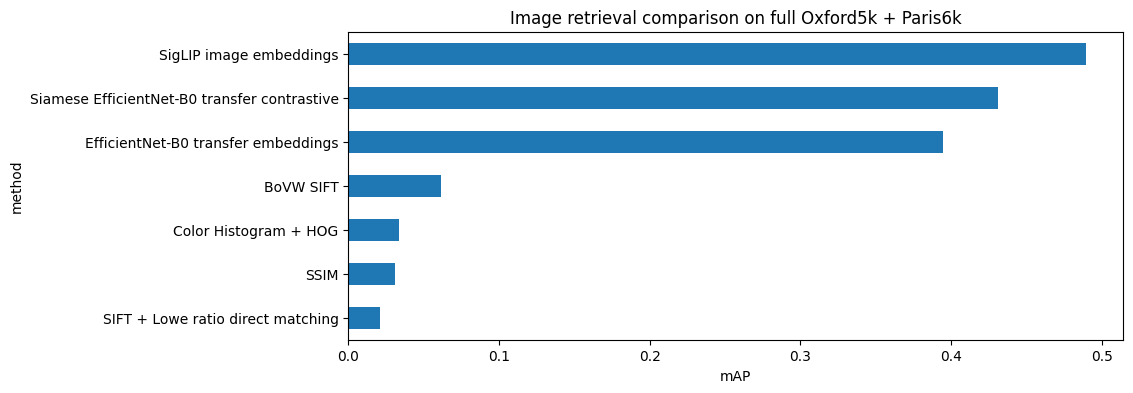

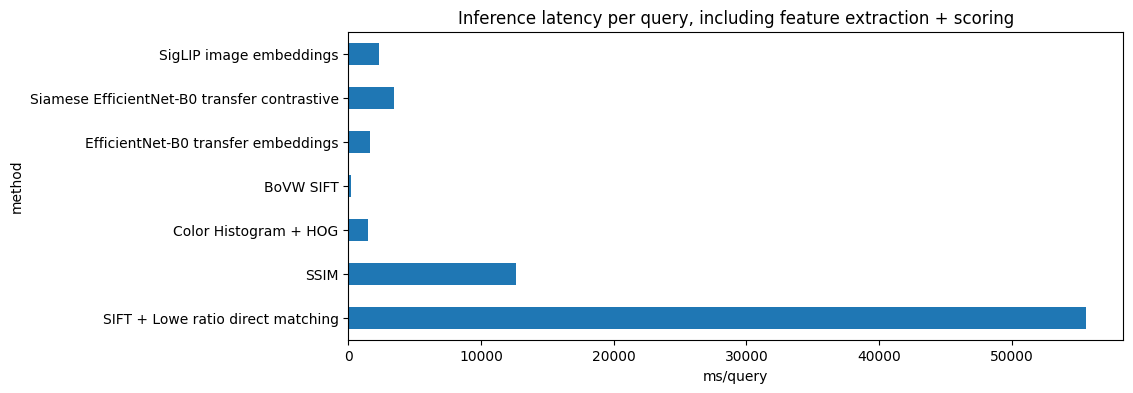

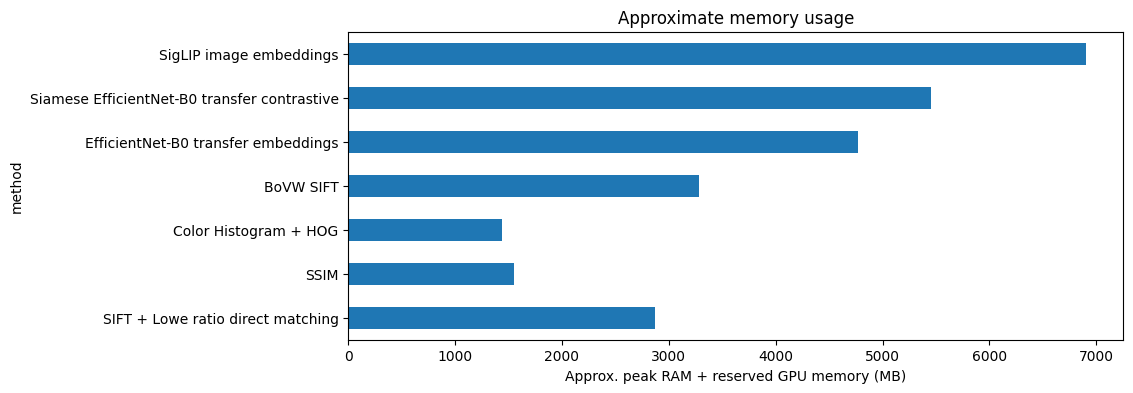

In [15]:
results_df = pd.DataFrame(results)

if not results_df.empty:
    sort_cols = ["mAP", f"F1@{F1_K}"]
    display_cols = [
        "method", "mAP", "P@1", "P@5", "P@10", "R@1", "R@5", "R@10", f"F1@{F1_K}",
        "inference_latency_ms_per_query", "seconds",
        "memory_usage_mb", "peak_ram_mb", "peak_gpu_allocated_mb", "peak_gpu_reserved_mb",
    ]
    display_cols = [c for c in display_cols if c in results_df.columns]
    display(results_df[display_cols].sort_values(sort_cols, ascending=False).reset_index(drop=True))

    plot_df = results_df.set_index("method").sort_values("mAP", ascending=True)

    ax = plot_df[["mAP"]].plot(kind="barh", figsize=(10, max(4, 0.45 * len(plot_df))), legend=False)
    ax.set_xlabel("mAP")
    ax.set_title("Image retrieval comparison on full Oxford5k + Paris6k")
    plt.show()

    ax = plot_df[["inference_latency_ms_per_query"]].plot(kind="barh", figsize=(10, max(4, 0.45 * len(plot_df))), legend=False)
    ax.set_xlabel("ms/query")
    ax.set_title("Inference latency per query, including feature extraction + scoring")
    plt.show()

    ax = plot_df[["memory_usage_mb"]].plot(kind="barh", figsize=(10, max(4, 0.45 * len(plot_df))), legend=False)
    ax.set_xlabel("Approx. peak RAM + reserved GPU memory (MB)")
    ax.set_title("Approximate memory usage")
    plt.show()
else:
    print("No results yet. Run at least one method section.")

## 14. Visualize top retrievals

Pick a method name from `scores_by_method.keys()` and a query index.

Available methods:
- Color Histogram + HOG
- SSIM
- SIFT + Lowe ratio direct matching
- BoVW SIFT
- EfficientNet-B0 transfer embeddings
- Siamese EfficientNet-B0 transfer contrastive
- SigLIP image embeddings


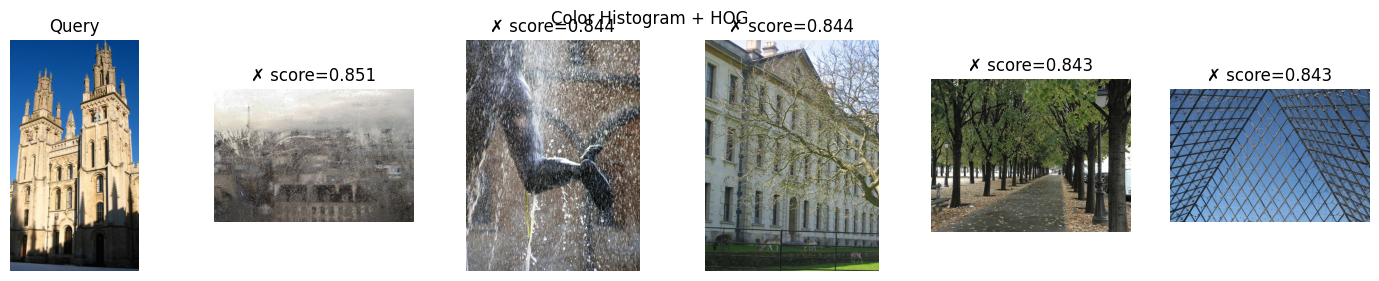

In [18]:
print("Available methods:")
for name in scores_by_method.keys():
    print("-", name)

if scores_by_method:
    method_name = list(scores_by_method.keys())[0]
    query_id = 0
    show_top_results(query_id, scores_by_method[method_name], title=method_name, top_k=5)

## 15. References

- Oxford Buildings Dataset: James Philbin, Ondřej Chum, Michael Isard, Josef Sivic, Andrew Zisserman, *Object retrieval with large vocabularies and fast spatial matching*, CVPR 2007.
- Paris Buildings Dataset: James Philbin, Ondřej Chum, Michael Isard, Josef Sivic, Andrew Zisserman, *Lost in Quantization: Improving Particular Object Retrieval in Large Scale Databases*, CVPR 2008.
- Revisited Oxford and Paris: Filip Radenović, Ahmet Iscen, Giorgos Tolias, Yannis Avrithis, Ondřej Chum, *Revisiting Oxford and Paris: Large-Scale Image Retrieval Benchmarking*, CVPR 2018.
- SIFT: David G. Lowe, *Distinctive Image Features from Scale-Invariant Keypoints*, IJCV 2004.
- HOG: Navneet Dalal and Bill Triggs, *Histograms of Oriented Gradients for Human Detection*, CVPR 2005.
- EfficientNet: Mingxing Tan and Quoc V. Le, *EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks*, ICML 2019.
- SigLIP: Xiaohua Zhai et al., *Sigmoid Loss for Language Image Pre-Training*, ICCV 2023.